## Basit Polinom Regresyon İle 2.El araç Piyasası Tahmini

In [62]:
#Kutuphanelerin indirilimesi
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [64]:
#test ve egitim veri setleri
x_train=[[6000],[8200],[9000],[14200],[16200]]
y_train=[[86000],[82000],[78000],[75000],[70000]]

x_test=[[1700],[2600],[11000],[14000],[17500]]
y_test=[[94000],[94400],[73000],[83000],[75000]]

In [66]:
#Linear regresyon olustur.
model=LinearRegression()
model.fit(x_train,y_train)
xx=np.linspace(0,25000,150000)
yy=model.predict(xx.reshape(xx.shape[0],1))


In [68]:
#modeli polinom yapmak icin derece ayarlari yapalim.
polinom_derecesi=PolynomialFeatures(degree=2)
x_train_polinom=polinom_derecesi.fit_transform(x_train)
x_test_polinom=polinom_derecesi.transform(x_test)

In [70]:
#Polinom regresyon algoritmasini egitelim.
polinom_regresyon=LinearRegression()
polinom_regresyon.fit(x_train_polinom,y_train)

LinearRegression()

In [72]:
xx_polinom=polinom_derecesi.transform(xx.reshape(xx.shape[0],1))
yy_polinom=polinom_regresyon.predict(xx_polinom)
print(xx_polinom)

[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.00000000e+00 1.66667778e-01 2.77781482e-02]
 [1.00000000e+00 3.33335556e-01 1.11112593e-01]
 ...
 [1.00000000e+00 2.49996667e+04 6.24983333e+08]
 [1.00000000e+00 2.49998333e+04 6.24991667e+08]
 [1.00000000e+00 2.50000000e+04 6.25000000e+08]]


In [74]:
#model parametleri
print(polinom_regresyon.intercept_)
print(polinom_regresyon.coef_)

[99393.54577621]
[[ 0.00000000e+00 -2.66306426e+00  5.67196997e-05]]


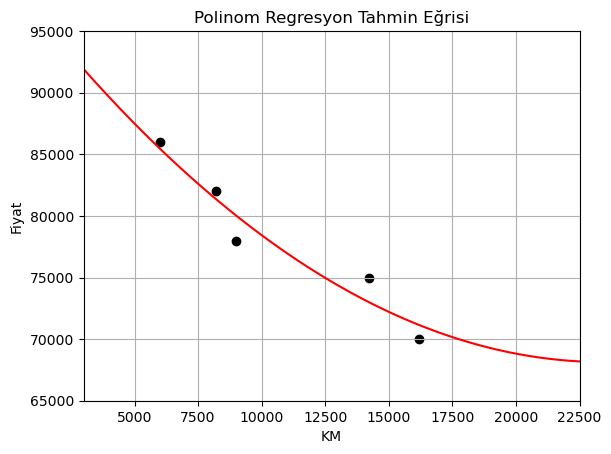

In [76]:
#Grafik-1 Polinom Regresyon ve Egitim Veri Seti
plt.figure()
plt.title("Polinom Regresyon Tahmin Eğrisi")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(xx,polinom_regresyon.predict(xx_polinom),c="r",linestyle="-")
plt.axis([3000,22500,65000,95000])
plt.grid(True)
plt.scatter(x_train,y_train,color="black")
plt.show()

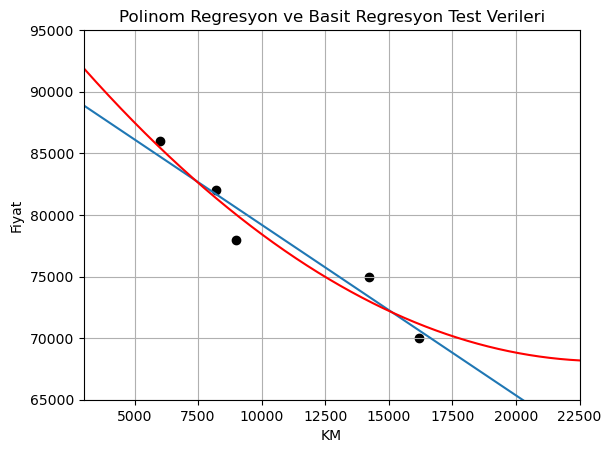

In [77]:
#Grafik-2 Polinom Regresyon ve Dogrusal Regresyon karsilastirma
plt.figure()
plt.title("Polinom Regresyon ve Basit Regresyon Test Verileri")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(xx,yy)
plt.plot(xx,polinom_regresyon.predict(xx_polinom),c="red",linestyle="-")
plt.axis([3000,22500,65000,95000])
plt.grid(True)
plt.scatter(x_train,y_train,color="black")
plt.show()


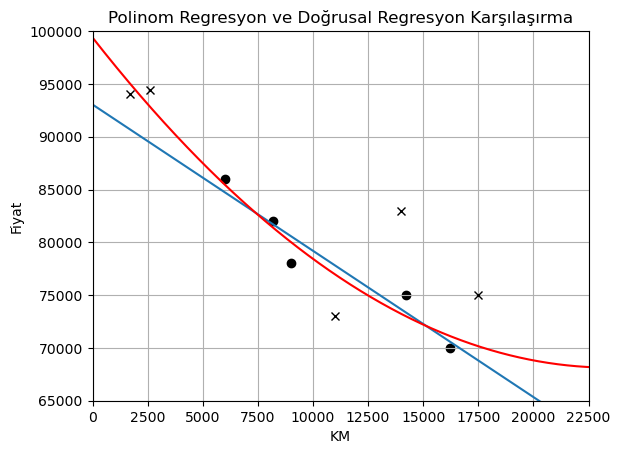

In [79]:
#Grafik-3 Polinom ve Basit Regresyon Test veri setleri
plt.figure()
plt.title("Polinom Regresyon ve Doğrusal Regresyon Karşılaşırma")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(xx,yy)
plt.plot(xx,polinom_regresyon.predict(xx_polinom),c='r',linestyle="-")
plt.axis([0,22500,65000,100000])
plt.grid(True)
plt.scatter(x_train,y_train,color="black")
plt.plot(x_test,y_test,"x",color="k")
plt.show()


In [81]:
#Bu 2 modelin test verileri uzerindeki basarilariniı olcelim.
print("Basit Doğrusal Regresyon R^2: ",model.score(x_test,y_test))
print("Polinom Regresyon R^2: ",polinom_regresyon.score(x_test_polinom,y_test))


Basit Doğrusal Regresyon R^2:  0.5518147334399546
Polinom Regresyon R^2:  0.6641120624358704


In [82]:
#polinom derecelerini arttirarak (3,4,5) tahminlere bakalim.
polinom_derecesi=PolynomialFeatures(degree=3)
x_train_polinom=polinom_derecesi.fit_transform(x_train)
x_test_polinom=polinom_derecesi.transform(x_test)

In [86]:
polinom_regresyon=LinearRegression()
polinom_regresyon.fit(x_train_polinom,y_train)

xx_polinom=polinom_derecesi.transform(xx.reshape(xx.shape[0],1))
yy_polinom=polinom_regresyon.predict(xx_polinom)

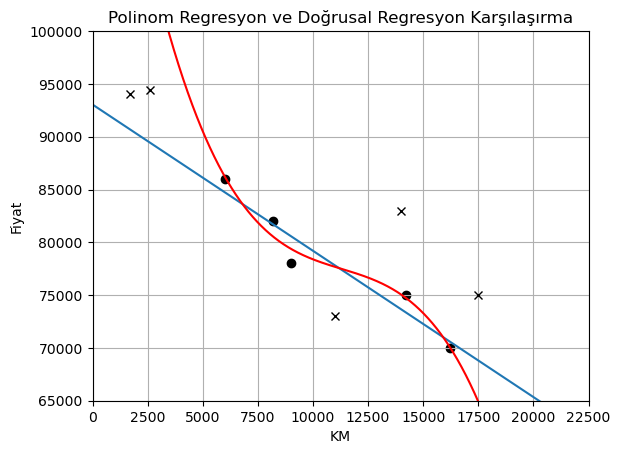

In [88]:
#Grafik-4 : 3.derece Polinom Tahmin egrisi
plt.figure()
plt.title("Polinom Regresyon ve Doğrusal Regresyon Karşılaşırma")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(xx,yy)
plt.plot(xx,polinom_regresyon.predict(xx_polinom),c='r',linestyle="-")
plt.axis([0,22500,65000,100000])
plt.grid(True)
plt.scatter(x_train,y_train,color="black")
plt.plot(x_test,y_test,"x",color="k")
plt.show()

In [89]:
#3.derece ve basit regresyon score degerleri
print("Basit Doğrusal Regresyon R^2: ",model.score(x_test,y_test))
print("Polinom Regresyon R^2: ",polinom_regresyon.score(x_test_polinom,y_test))

Basit Doğrusal Regresyon R^2:  0.5518147334399546
Polinom Regresyon R^2:  -0.9581221520136736
